# Sesión 11 - Reinforcement Learning from Human Feedback (RLHF)

> En la presente sesión, vamos a realizar una introducción a uno de los campos más prometedores para la aplicación de algoritmos de aprendizaje por refuerzo: ajustar modelos de lenguage en base a preferencias humanas. Este campo, el cual se denomina **Reinforcement Learning from Human Feedback (RLHF)** es una forma de ajustar grandes modelo de lenguage natural pre-entrenados, y transferirlos a tareas concretas, especializadas. Veremos que estos algoritmos hacen uso de feedback humano (u otros modelos) para entrenar una policy network (siguiendo **PPO**) en base a interacción entre el modelo de lenguage natural y el humano.




---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.



---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda update --all
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```




---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [1]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount='/content/gdrive'
drive_root = mount + "/My Drive/VIU/08_AR_MIAR/sesiones_practicas/sesion_practica_rlhf"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [2]:
# Switch to the directory on the Google Drive that you want to use
import os
if IN_COLAB:
  print("We're running Colab")

  if IN_COLAB:
    # Mount the Google Drive at mount
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    # Create drive_root if it doesn't exist
    create_drive_root = True
    if create_drive_root:
      print("\nColab: making sure ", drive_root, " exists.")
      os.makedirs(drive_root, exist_ok=True)

    # Change to the directory
    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
# Verify we're in the correct working directory
%pwd
print("Archivos en el directorio: ")
print(os.listdir())

We're running Colab
Colab: mounting Google drive on  /content/gdrive
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

Colab: making sure  /content/gdrive/My Drive/VIU/08_AR_MIAR/sesiones_practicas/sesion_practica_rlhf  exists.

Colab: Changing directory to  /content/gdrive/My Drive/VIU/08_AR_MIAR/sesiones_practicas/sesion_practica_rlhf
/content/gdrive/My Drive/VIU/08_AR_MIAR/sesiones_practicas/sesion_practica_rlhf
Archivos en el directorio: 
['images', '08MIAR_rlhf.ipynb', '=0.4.0', '=3.8.1', '=0.1.2']


---
### 1.4. Instalar librerías necesarias


In [3]:
#import locale
#locale.getpreferredencoding = lambda: "UTF-8"
%pip install transformers trl
%pip wand
%pip evaluate>=0.4.0
%pip nltk>=3.8.1
%pip rouge-score>=0.1.2

ERROR: unknown command "wand"
ERROR: unknown command "evaluate"
ERROR: unknown command "nltk"
ERROR: unknown command "rouge-score"


---
### 1.5.Acerca de las librerías para RL

Librería para trabajar con nuestros entornos: gym (https://gym.openai.com/) \
Librería para trabajar con deep learning: tensorflow (https://www.tensorflow.org/) \
Librería para desarrollar soluciones de RL a alto nivel: keras-rl (https://github.com/keras-rl/keras-rl) \


---
## **PARTE 2** - *RLHF*


---
### 2.1. RLHF Vista General

Literatura interesante en el tema:
- https://huggingface.co/blog/rlhf
- https://huggingface.co/docs/trl/index
- https://huyenchip.com/2023/05/02/rlhf.html
- https://www.youtube.com/watch?v=2MBJOuVq380
- https://huggingface.co/docs/trl/ppo_trainer



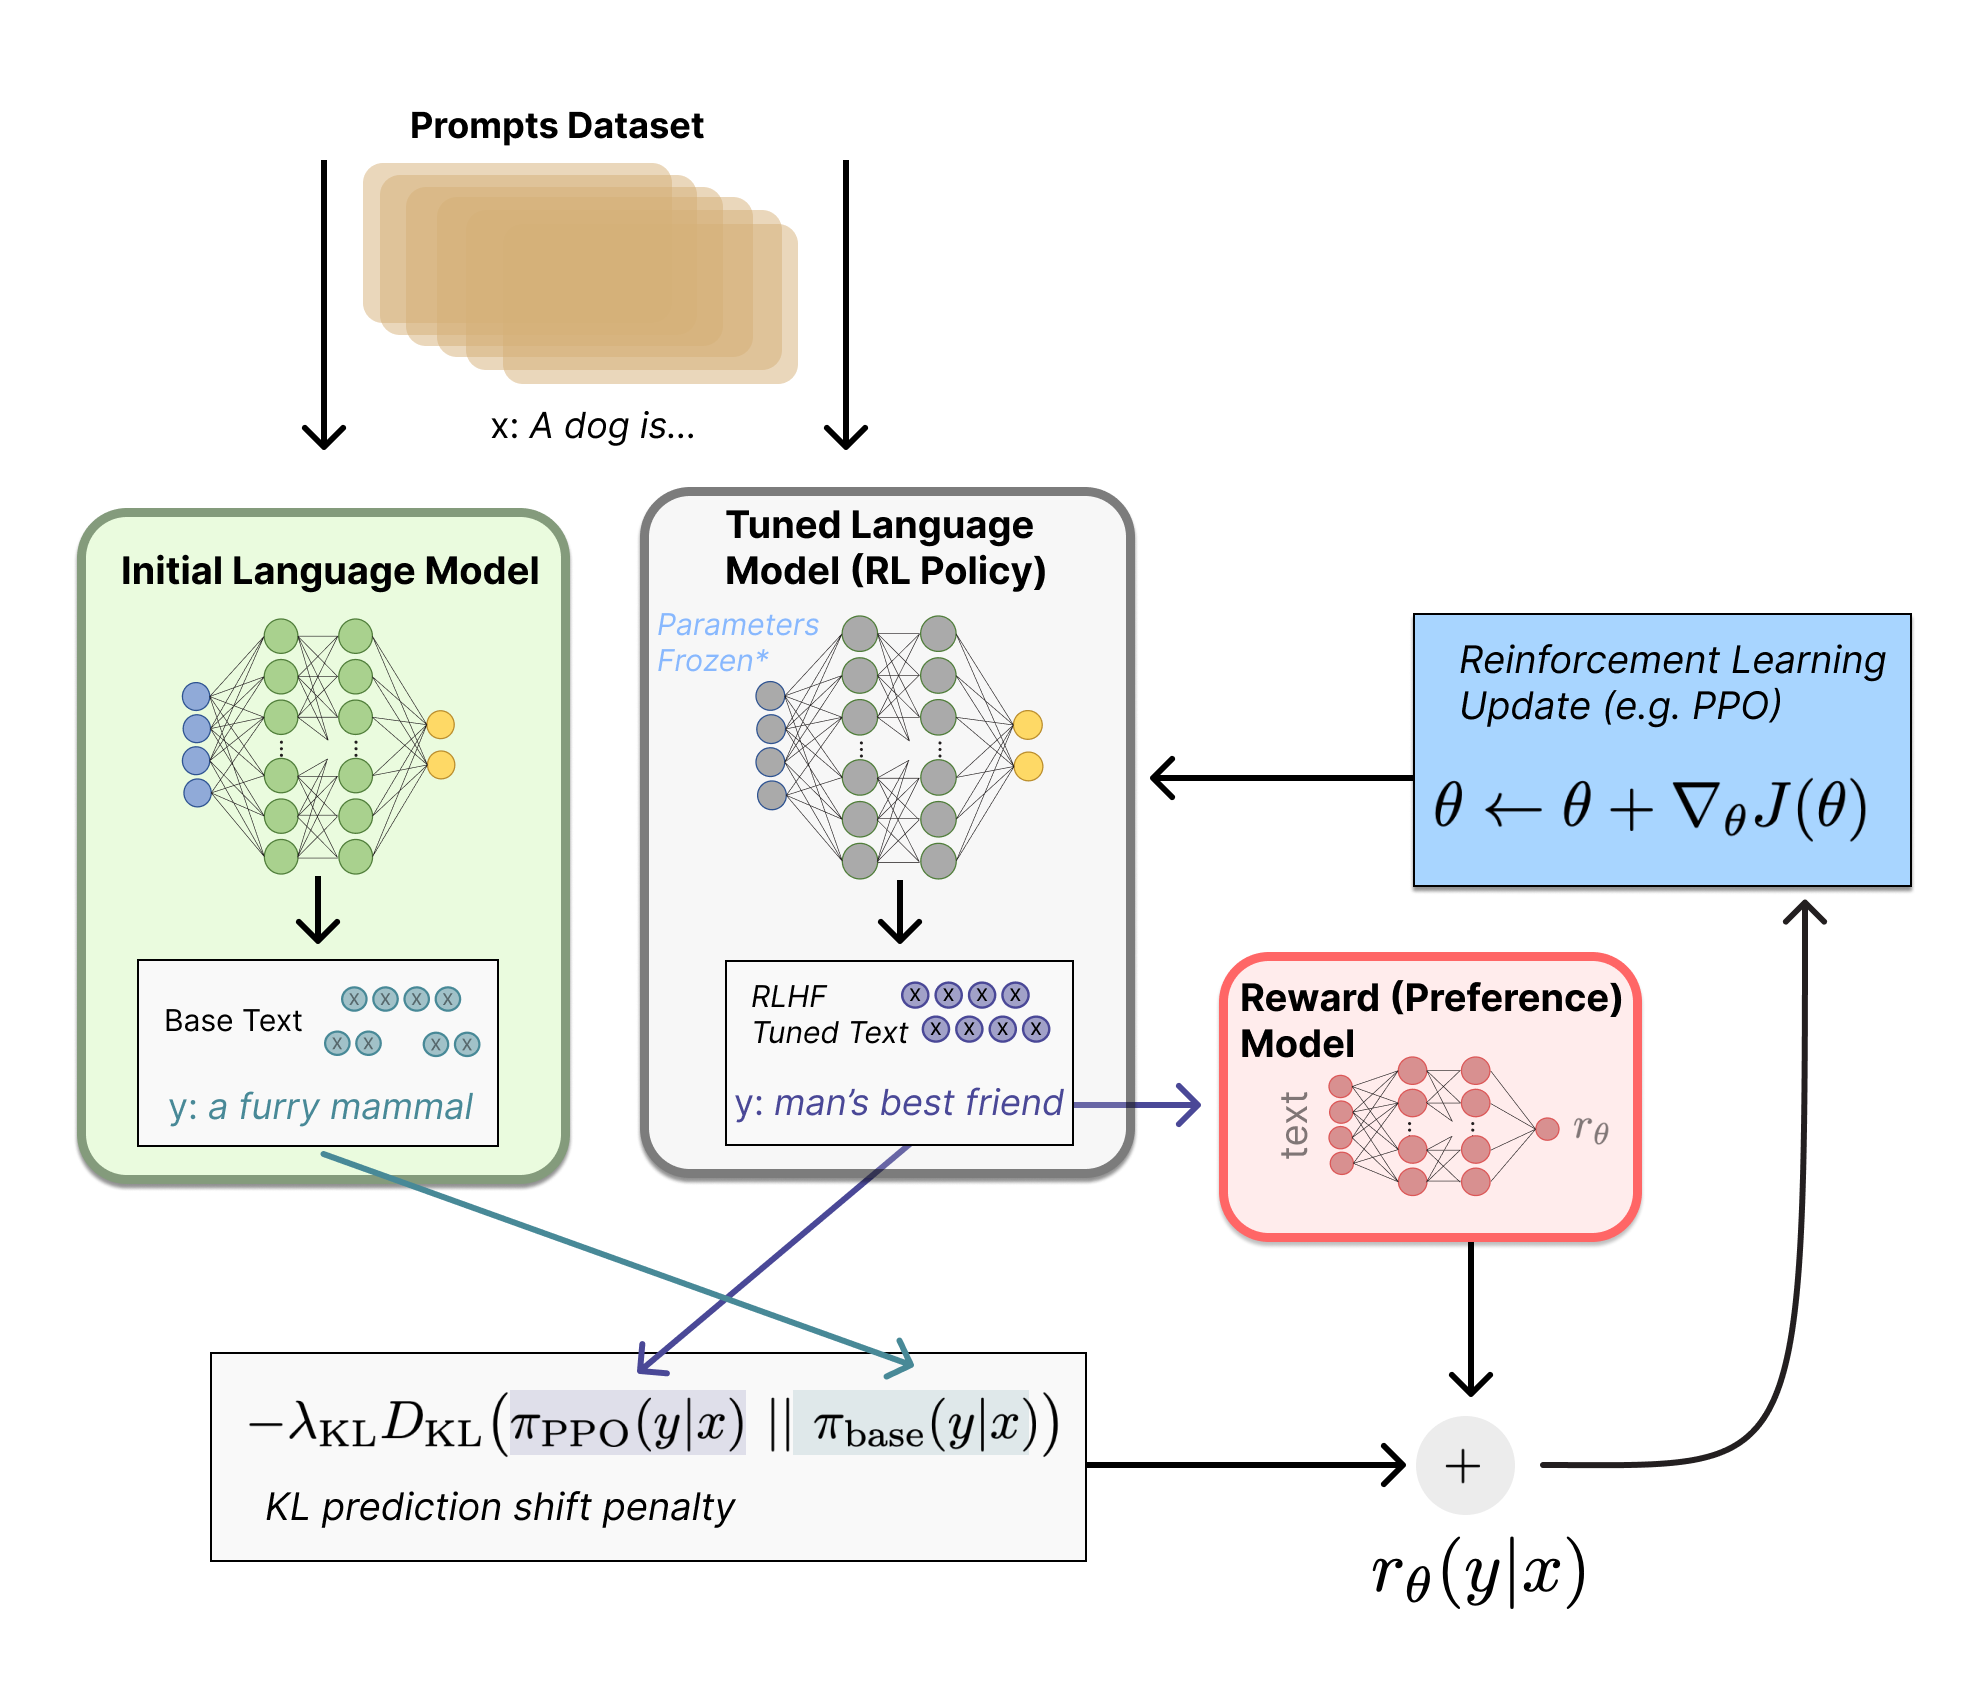

In [ ]:
from IPython import display
display.Image("images/rlhf.png", width = 700, height = 500)

---
### 2.2. Ejemplo: Tunear GPT2 para generar respuestas positivas

Acerca del dataset:
- https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [4]:
# 1. Imports necesarios
import torch

import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import pandas as pd
tqdm.pandas()

from transformers import pipeline, AutoTokenizer # Librería de Transformers - especializada en este tipo de arquitecturas
from datasets import load_dataset

from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead # Librerías especializadas para tuner LLMs con RL
from trl.core import LengthSampler

In [5]:
# Configuraciones
config = PPOConfig(
    model_name="lvwerra/gpt2-imdb",
    learning_rate=1.41e-5,
)

sent_kwargs = {"return_all_scores": True, "function_to_apply": "none", "batch_size": 16}

In [6]:
# 2. Preparar función para la carga de datos
def build_dataset(config, dataset_name="imdb", input_min_text_length=2, input_max_text_length=8):
    """
    Build dataset for training. This builds the dataset from `load_dataset`, one should
    customize this function to train the model on its own dataset.

    Args:
        dataset_name (`str`):
            The name of the dataset to be loaded.

    Returns:
        dataloader (`torch.utils.data.DataLoader`):
            The dataloader for the dataset.
    """
    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    tokenizer.pad_token = tokenizer.eos_token
    # load imdb with datasets
    ds = load_dataset(dataset_name, split="train")
    ds = ds.rename_columns({"text": "review"})
    ds = ds.filter(lambda x: len(x["review"]) > 200, batched=False)

    input_size = LengthSampler(input_min_text_length, input_max_text_length)

    def tokenize(sample):
        sample["input_ids"] = tokenizer.encode(sample["review"])[: input_size()]
        sample["query"] = tokenizer.decode(sample["input_ids"])
        return sample

    ds = ds.map(tokenize, batched=False)
    ds.set_format(type="torch")
    return ds

# Función para lectura amigable de los datos
def collator(data):
    return dict((key, [d[key] for d in data]) for key in data[0])

# Instanciamos el dataset
dataset = build_dataset(config, dataset_name="imdb", input_min_text_length=2, input_max_text_length=8)
print(dataset["review"])

tokenizer_config.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24895 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1168 > 1024). Running this sequence through the model will result in indexing errors
IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [7]:
# 3. Cargar LLMs pre-entrenados. Cargamos el modelo GPT2 con una cabeza de valores y el tokenizador.
# Cargamos el modelo dos veces; el primer modelo se optimiza mientras que el segundo sirve de referencia para calcular la divergencia KL desde el punto de partida.
# Esto sirve como señal de recompensa adicional en el entrenamiento PPO para asegurarse de que el modelo optimizado no se desvía demasiado del modelo lingüístico original.

# Modelos a ajustar
model = AutoModelForCausalLMWithValueHead.from_pretrained(config.model_name)     # El modelo que especializaremos
ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(config.model_name) # Modelo de referencia - evitar "olvidar" información
# Tokenizador de texto - especifico para cada LLM
tokenizer = AutoTokenizer.from_pretrained(config.model_name)
tokenizer.pad_token = tokenizer.eos_token
# Preparar formato de generación de respuestas por parte del LLM.
# Utilizamos el muestreo y nos aseguramos de que el muestreo top-k y el muestreo de núcleos están desactivados, así como una longitud mínima.
gen_kwargs = {"min_length": -1, "top_k": 0.0, "top_p": 1.0, "do_sample": True, "pad_token_id": tokenizer.eos_token_id}

pytorch_model.bin:   0%|          | 0.00/548M [00:00<?, ?B/s]

In [8]:
# 4. Reward function: BERT Classifier.
# La salida del modelo BERT son las pre-activaciones (logits) para la clase positiva y negativa.
# Usaremos estos valores como factor de relevancia a la hora de actualizar el LLM mediante PPO.

# Inicializamos nuestro entrenador basado en PPO
ppo_trainer = PPOTrainer(config, model, ref_model, tokenizer, dataset=dataset, data_collator=collator)

device = ppo_trainer.accelerator.device
if ppo_trainer.accelerator.num_processes == 1:
    device = 0 if torch.cuda.is_available() else "cpu"  # to avoid a `pipeline` bug
sentiment_pipe = pipeline("sentiment-analysis", model="lvwerra/distilbert-imdb", device=device)

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [9]:
def forward_bert_display():
  res = sentiment_pipe(text, **sent_kwargs)
  print("Sentence: " + text)
  print("Negative sentiment score: " + str(res[0][0]["score"]))
  print("Positive sentiment score: " + str(res[0][1]["score"]))

# Vamos a realizar algunas pruebas:
text = "this movie was really bad!!"
forward_bert_display()

text = "marvel movies are getting worse"
forward_bert_display()

text = "the plot is deep and novel"
forward_bert_display()

text = "i would go to see the movie again."
forward_bert_display()

Sentence: this movie was really bad!!
Negative sentiment score: 2.3350486755371094
Positive sentiment score: -2.726576566696167
Sentence: marvel movies are getting worse
Negative sentiment score: 1.8307411670684814
Positive sentiment score: -2.3056650161743164
Sentence: the plot is deep and novel
Negative sentiment score: -2.283787250518799
Positive sentiment score: 2.512861728668213
Sentence: i would go to see the movie again.
Negative sentiment score: -0.7236757278442383
Positive sentiment score: 0.799839973449707


In [ ]:
# 5. Model Fine-tuning
#   1. Obtener respuestas de text0 de la policy network (GPT-2)
#   2. Obtener los sentimientos para las queys/respuestas utilizando BERT
#   3. Optimizar la policy con PPO usando (query, respuesta, recompensa) triplete

output_min_length = 4
output_max_length = 16
output_length_sampler = LengthSampler(output_min_length, output_max_length)

for epoch, batch in tqdm(enumerate(ppo_trainer.dataloader)):
    query_tensors = batch["input_ids"]

    #### Get response from gpt2
    response_tensors = []
    for query in query_tensors:
        gen_len = output_length_sampler()
        gen_kwargs["max_new_tokens"] = gen_len
        response = ppo_trainer.generate(query, **gen_kwargs)
        response_tensors.append(response.squeeze()[-gen_len:])
    batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]

    #### Compute sentiment score
    texts = [q + r for q, r in zip(batch["query"], batch["response"])]
    pipe_outputs = sentiment_pipe(texts, **sent_kwargs)
    rewards = [torch.tensor(output[1]["score"]) for output in pipe_outputs]

    #### Run PPO step
    stats = ppo_trainer.step(query_tensors, response_tensors, rewards)
    ppo_trainer.log_stats(stats, batch, rewards)

In [ ]:
# 6. Inspeccionar resultados
#### get a batch from the dataset
bs = 32
game_data = dict()
dataset.set_format("pandas")
df_batch = dataset[:].sample(bs)
game_data["query"] = df_batch["query"].tolist()
query_tensors = df_batch["input_ids"].tolist()

response_tensors_ref, response_tensors = [], []

#### get response from gpt2 and gpt2_ref
for i in range(bs):
    gen_len = output_length_sampler()
    output = ref_model.generate(
        torch.tensor(query_tensors[i]).unsqueeze(dim=0).to(device), **gen_kwargs
    ).squeeze()[-gen_len:]
    response_tensors_ref.append(output)
    output = model.generate(
        torch.tensor(query_tensors[i]).unsqueeze(dim=0).to(device), **gen_kwargs
    ).squeeze()[-gen_len:]
    response_tensors.append(output)

#### decode responses
game_data["response (before)"] = [tokenizer.decode(response_tensors_ref[i]) for i in range(bs)]
game_data["response (after)"] = [tokenizer.decode(response_tensors[i]) for i in range(bs)]

#### sentiment analysis of query/response pairs before/after
texts = [q + r for q, r in zip(game_data["query"], game_data["response (before)"])]
game_data["rewards (before)"] = [output[1]["score"] for output in sentiment_pipe(texts, **sent_kwargs)]

texts = [q + r for q, r in zip(game_data["query"], game_data["response (after)"])]
game_data["rewards (after)"] = [output[1]["score"] for output in sentiment_pipe(texts, **sent_kwargs)]

# store results in a dataframe
df_results = pd.DataFrame(game_data)
df_results

,query,response (before),response (after),rewards (before),rewards (after)
0,Looking through the,Looking through the window there is a stereo p...,Looking through the movie is both brilliant an...,-0.352954,2.708226
1,"Late, great","direction OK, but on",production. I enjoyed it,-0.067108,2.740497
2,Why review good movies,not bad movies.<br /><,but how can anyone praise this one,-0.543332,0.820930
3,This one was marred by,by a mess. The complete cast made Mario,"by beautiful cinematography, winning its spot in",-2.752102,-1.103977
4,Of course the average,would not believe that,as it gets.,-1.337211,0.814242
5,"""National Lampoon Goes to","Heaven"" isn't any stretch of the","it again, and it is great movie",0.024872,2.664347
6,Friz,Friz).<|endoftext|>,fun thrill you feel pure speed,-0.401041,2.464717
7,This is one,This is one of their most engaging masterpiece...,"This is one of a class of great actors, that",2.890012,2.242106
8,"This, the direct-to",the direct-to-video method of investigation r...,the direct-to-home video-movie about a million,-1.461664,0.774695
9,Journey to the Center of the,(South Western),"versatility and knowledge,",1.852125,2.525934


---

Otros ejemplos y recursos interesantes:

- Caso de uso para mejorar el resumen de textos:
  - https://wandb.ai/carperai/summarize_RLHF/reports/Implementing-RLHF-Learning-to-Summarize-with-trlX--VmlldzozMzAwODM2
  - https://github.com/CarperAI/trlx/tree/main/examples/summarize_rlhf
  - https://arxiv.org/pdf/2009.01325.pdf